# Gatchina

In [3]:
indicators = [
    # 'Численность постоянного населения (тысяч человек, среднегодовая)',
    # 'Численность работающих в экономике по крупным и средним предприятиям (тысяч человек)',
    # 'Уровень среднемесячной заработной платы по крупным и средним предприятиям (в процентах от среднего уровня по Ленинградской области)',
    # 'Уровень зарегистрированной безработицы (в процентах от экономически активного населения)',
    # 'Объем инвестиций в экономику (тысяч рублей на душу населения)',

    # 'Динамика объема отгруженных товаров собственного производства, выполненных работ и услуг по организациям, не относящимся к субъектам малого предпринимательства (среднегодовой индекс, в процентах)',
    # 'Туристский поток, всего (тысяч человек в год)',
    # 'Динамика объема отгруженных товаров собственного производства, выполненных работ и услуг малыми предприятиями (среднегодовой индекс, в процентах)',
    # 'Число предпринимателей без образования юридического лица (единиц)',

    # 'Уровень обеспеченности населения жилищным фондом (кв.м/чел)',
    # 'Протяженность тепловых и паровых сетей, нуждающихся в замене (процентов от общей протяженности сетей)',
    # 'Протяженность уличной водопроводной сети, нуждающейся в замене (процентов от общей протяженности сетей)',
    # 'Протяженность уличной канализационной сети, нуждающейся в замене (процентов от общей протяженности сетей)',
    # 'Удельный вес автомобильных дорог местного значения с твердым покрытием (в процентах от общей протяженности дорог)',

    'Уровень удовлетворенности жителей услугами учреждений детского дошкольного образования (процент от опрошенных)',
    'Уровень удовлетворенности жителей услугами общеобразовательных учреждений (процент от опрошенных)',
    'Уровень удовлетворенности жителей услугами учреждений дополнительного образования (процент от опрошенных)',
    'Уровень удовлетворенности жителей услугами учреждениях культурно-досугового типа (процент от опрошенных)',
    'Оборот розничной торговли, общественного питания и объем платных услуг населению по организациям, не относящимся к субъектам малого предпринимательства (тыс.руб./чел.)',
    'Единовременная пропускная способность спортивных сооружений (процент от норматива)',
    'Спортивные залы, площадь пола (процент от норматива)',
    'Плоскостные спортивные сооружения, га (процент от норматива)',
]

In [4]:
goals = [
    """
    Стратегической целью приоритетного направления «Услуги» является реализация комплекса вопросов социальной политики, развития сферы услуг, направленных на повышение качества жизни, создание условий для развития экономического комплекса, удовлетворение спроса всех категорий и слоев населения (в том числе маломобильных групп населения и инвалидов), а также внешних потребителей, в том числе путем развития направления «индивидуализации услуг», создания условий для развития сети организаций различных организационно-правовых форм и форм собственности, развитие сектора негосударственных некоммерческих организаций в сфере оказания услуг населению, в том числе создание механизма привлечения их на конкурсной основе к выполнению муниципального заказа по оказанию услуг населению, создание прозрачной и конкурентной системы поддержки негосударственных некоммерческих организаций на уровне муниципального района, оказывающих услуги населению. Реализация данного приоритета также направлена на обеспечение условий реализации функции МО «Город Гатчина» в качестве центра обслуживания регионального уровня.
    """
    # mo
    'Повышение качества человеческого капитала на основе инновационного социально ориентированного типа экономического развития.',
    # gatchina
    'Создание многоотраслевого полюса роста инновационной экономики в рамках системы Санкт-Петербургской агломерации на основе формирования высокого качества городской среды',
]

## Оценка напрямую

In [25]:
from src import Agent, Model
from pydantic import Field

class AgentResponse(Model):
    scores : list[int] = Field(description='Оценки')

prompt = f"""
Ты эксперт в сфере стратегического и территориального планирования.
Выстави каждому показателю оценку в соответствии с тем, насколько он способствует достижению заданной цели.
ВАЖНО: количество оценок должно совпадать с количеством показателей
---
ЦЕЛЬ:
{goals[0]}
---
ШКАЛА ОЦЕНКИ:
0 - не влияет
1 - слабое влияние (косвенный или незначительный вклад)
2 - частичное влияние (опосредованный вклад)
3 - сильное влияние  (прямой вклад)
"""

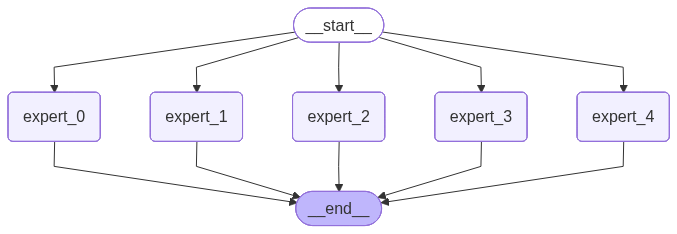

In [26]:
import random
from tqdm import tqdm

N_AGENTS = 5

from typing import TypedDict, Annotated
from operator import add

class State(TypedDict):
    indicators : list[str]
    results : Annotated[list[dict[str,int]], add]

def expert_node(state : State):
    inds = state['indicators'].copy()
    random.shuffle(inds)
    scores = []

    agent = Agent(system_prompt=prompt, 
        response_format=AgentResponse
    )    
    res = agent.run(str(inds))
    scores = res.scores
    if len(scores) != len(inds):
        return {}
    return {
        'results': [{
            i:s for i,s in zip(inds,res.scores)
        }]
    }


from langgraph.graph import StateGraph, START, END

graph = StateGraph(State)
for i in range(N_AGENTS):
    node_name = f'expert_{i}'
    graph.add_node(node_name, expert_node)
    graph.add_edge(START, node_name)
    graph.add_edge(node_name, END)
    
app = graph.compile()
app

In [27]:
res = app.invoke({
    'indicators': indicators,
    'result': []
}, debug=True)

[values] {'indicators': ['Уровень удовлетворенности жителей услугами учреждений детского дошкольного образования (процент от опрошенных)', 'Уровень удовлетворенности жителей услугами общеобразовательных учреждений (процент от опрошенных)', 'Уровень удовлетворенности жителей услугами учреждений дополнительного образования (процент от опрошенных)', 'Уровень удовлетворенности жителей услугами учреждениях культурно-досугового типа (процент от опрошенных)', 'Оборот розничной торговли, общественного питания и объем платных услуг населению по организациям, не относящимся к субъектам малого предпринимательства (тыс.руб./чел.)', 'Единовременная пропускная способность спортивных сооружений (процент от норматива)', 'Спортивные залы, площадь пола (процент от норматива)', 'Плоскостные спортивные сооружения, га (процент от норматива)'], 'results': []}
[updates] {'expert_1': {'results': [{'Уровень удовлетворенности жителей услугами учреждений дополнительного образования (процент от опрошенных)': 3, '

In [29]:
import pandas as pd

df = pd.DataFrame.from_dict({indicator:[r[indicator] for r in res['results']] for indicator in res['indicators']})
df.describe()

,Уровень удовлетворенности жителей услугами учреждений детского дошкольного образования (процент от опрошенных),Уровень удовлетворенности жителей услугами общеобразовательных учреждений (процент от опрошенных),Уровень удовлетворенности жителей услугами учреждений дополнительного образования (процент от опрошенных),Уровень удовлетворенности жителей услугами учреждениях культурно-досугового типа (процент от опрошенных),"Оборот розничной торговли, общественного питания и объем платных услуг населению по организациям, не относящимся к субъектам малого предпринимательства (тыс.руб./чел.)",Единовременная пропускная способность спортивных сооружений (процент от норматива),"Спортивные залы, площадь пола (процент от норматива)","Плоскостные спортивные сооружения, га (процент от норматива)"
count,5.0,5.0,5.0,5.000000,5.000000,5.0,5.0,5.0
mean,3.0,3.0,3.0,2.800000,2.800000,2.0,2.0,2.0
std,0.0,0.0,0.0,0.447214,0.447214,0.0,0.0,0.0
min,3.0,3.0,3.0,2.000000,2.000000,2.0,2.0,2.0
25%,3.0,3.0,3.0,3.000000,3.000000,2.0,2.0,2.0
50%,3.0,3.0,3.0,3.000000,3.000000,2.0,2.0,2.0
75%,3.0,3.0,3.0,3.000000,3.000000,2.0,2.0,2.0
max,3.0,3.0,3.0,3.000000,3.000000,2.0,2.0,2.0


In [30]:
df_long = pd.DataFrame([{
    'agent': a, 
    'indicator':i,
    'score':s
} for a,r in enumerate(res['results']) for i,s in r.items()])
df_long

,agent,indicator,score
0,0,"Плоскостные спортивные сооружения, га (процент...",2
1,0,"Спортивные залы, площадь пола (процент от норм...",2
2,0,Уровень удовлетворенности жителей услугами общ...,3
3,0,"Оборот розничной торговли, общественного питан...",3
4,0,Уровень удовлетворенности жителей услугами учр...,3
5,0,Уровень удовлетворенности жителей услугами учр...,3
6,0,Единовременная пропускная способность спортивн...,2
7,0,Уровень удовлетворенности жителей услугами учр...,3
8,1,Уровень удовлетворенности жителей услугами учр...,3
9,1,Уровень удовлетворенности жителей услугами общ...,3


### ICC (intraclass correlation)

https://en.wikipedia.org/wiki/Intraclass_correlation

2 - two way random (случайные эксперты из генеральной выборки)
1 - single measurement (используем отдельные оценик экспертов)

ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ:
- [0.00, 0.50) - poor 
- (0.50, 0.75) - moderate 
- (0.75, 0.90) - good
- (0.90, 1.00] - excellent

In [ ]:
from src import embedding
from sklearn.metrics.pairwise import cosine_similarity

emb_g = embedding.embed_query(goals[0])
for indicator in indicators:
    emb_i = embedding.embed_query(indicator)
    print(cosine_similarity(emb_g, emb_i).round(3), indicator)

In [31]:
import pingouin as pg

icc = pg.intraclass_corr(
    data=df_long,
    targets='indicator',
    raters='agent',
    ratings='score'
)
icc

,Type,Description,ICC,F,df1,df2,pval,CI95
0,ICC1,Single raters absolute,0.817232,23.357143,7,32,6.968939e-11,"[0.6, 0.95]"
1,ICC2,Single random raters,0.816993,22.551724,7,28,6.277498e-10,"[0.6, 0.95]"
2,ICC3,Single fixed raters,0.811688,22.551724,7,28,6.277498e-10,"[0.59, 0.95]"
3,ICC1k,Average raters absolute,0.957187,23.357143,7,32,6.968939e-11,"[0.88, 0.99]"
4,ICC2k,Average random raters,0.957121,22.551724,7,28,6.277498e-10,"[0.88, 0.99]"
5,ICC3k,Average fixed raters,0.955657,22.551724,7,28,6.277498e-10,"[0.88, 0.99]"


### Альфа Кронбаха

In [ ]:
pg.cronbach_alpha(df_long)

## Шкала Саати и AHP

In [70]:
import random

pairs = []

for i, ind_i in enumerate(indicators):
    for j, ind_j in enumerate(indicators):
        if j > i:
            pairs.append((ind_i, ind_j))

random.shuffle(pairs)

In [71]:
from src import Agent, Model
from typing import Literal
from pydantic import Field

class AgentResponse(Model):
    selection : Literal['a', 'b'] = Field(description='Показатель, вносящий больший вклад в достижение заданной цели')
    score : int = Field(ge=1, le=9, description='Насколько выбранный показатель превосходит второй согласно шкале Саати')

agent = Agent(system_prompt=f"""
    Ты эксперт в сфере стратегического и территориального планирования.
    Какой из двух показателей вносит больший вклад в достижение заданной цели и насколько больше согласно шкале Саати?
    ---
    ЦЕЛЬ:
    {goals[0]}
    ---
    ШКАЛА СААТИ:
    1 - равная значимость
    2 - промежуточное значение
    3 - слабое превосходство
    4 - промежуточное значение
    5 - сильное превосходство
    6 - промежуточное значение
    7 - очень сильное превосходство
    8 - промежуточное значение
    9 - абсолютное превосходство
    ---
    ФОРМАТ ОТВЕТА:
    choice,score
    ПРИМЕРЫ:
    - a,9
    - b,1
    - a,5
    """, 
    # response_format=AgentResponse
)

In [72]:
import pandas as pd
from tqdm import tqdm

df = pd.DataFrame(1.0, index=indicators, columns=indicators)

for ind_a, ind_b in tqdm(pairs):
    res = agent.run(str({'a': ind_a, 'b': ind_b}))
    choice,score = res.split(',') 
    if choice == 'a':
        i = ind_a
        j = ind_b
    else:
        i = ind_b
        j = ind_a

    score = int(score)
    df.loc[i,j] = score
    df.loc[j,i] = 1.0/score

100%|██████████| 10/10 [04:31<00:00, 27.16s/it]


In [73]:
df

,"Численность постоянного населения (тысяч человек, среднегодовая)",Численность работающих в экономике по крупным и средним предприятиям (тысяч человек),Уровень среднемесячной заработной платы по крупным и средним предприятиям (в процентах от среднего уровня по Ленинградской области),Уровень зарегистрированной безработицы (в процентах от экономически активного населения),Объем инвестиций в экономику Гатчинского муниципального района (тысяч рублей на душу населения)
"Численность постоянного населения (тысяч человек, среднегодовая)",1.0,0.142857,0.142857,0.142857,0.142857
Численность работающих в экономике по крупным и средним предприятиям (тысяч человек),7.0,1.000000,0.142857,7.000000,0.142857
Уровень среднемесячной заработной платы по крупным и средним предприятиям (в процентах от среднего уровня по Ленинградской области),7.0,7.000000,1.000000,7.000000,7.000000
Уровень зарегистрированной безработицы (в процентах от экономически активного населения),7.0,0.142857,0.142857,1.000000,0.142857
Объем инвестиций в экономику Гатчинского муниципального района (тысяч рублей на душу населения),7.0,7.000000,0.142857,7.000000,1.000000
